In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Rr_computation import compute_response_recovery # can be adapted to your own implementation

In [2]:
# ------------------------------
# Load Data
# ------------------------------
SouthHolland_data = pd.read_pickle(r"C:\Users\mjg9941\Documents\PhD_Research\Projects\SmartWater\Python_Projects\ERL_HotMoment\SouthHolland_WaterQualityData_Sept25toJan26.pkl")

site_data = {
    'CottageGrove': SouthHolland_data, 
}

parameters= ["SPCOND µS/CM"] # More parameters can be evaluated by adding them to the list

### Step i: Define Temporal Scale of Analysis

In [3]:
windows = [pd.Timedelta("24h")] #Several time windows can be tested at once


### Step ii: Compute response and recovery for all observations in a given time series.

In [4]:

all_results = []

for site, df in site_data.items():
    for w in windows:
        res = compute_response_recovery(
            df,
            parameters,
            window_length=w,
            step=pd.Timedelta("5min"),
            max_change=0.15
        )

        res["site"] = site
        res["window_length"] = w
        all_results.append(res)

results = pd.concat(all_results, ignore_index=True)

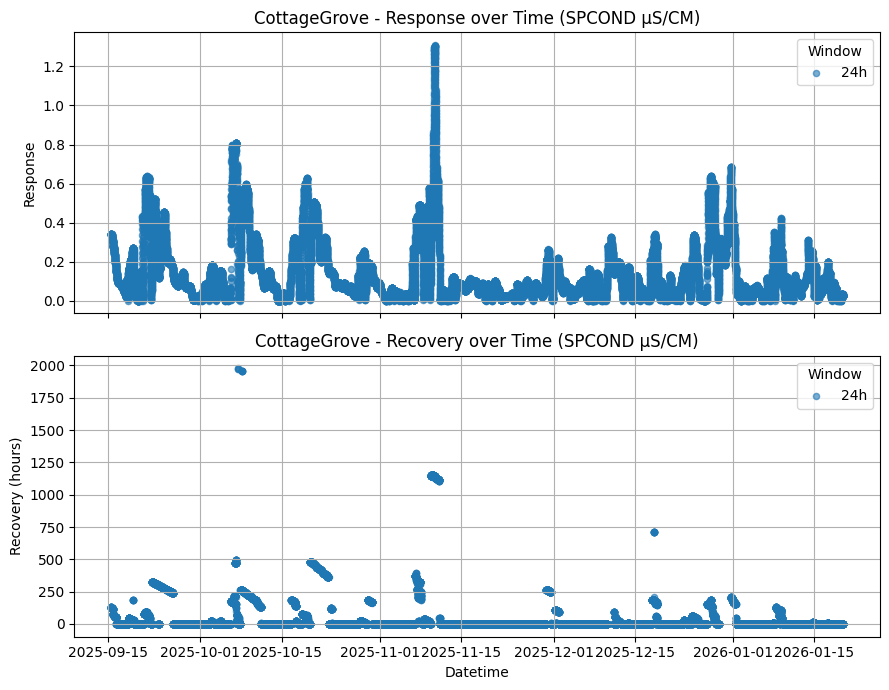

In [5]:
for site in results["site"].unique():
    
    df_site = results[results["site"] == site]
    
    if df_site.empty:
        print(f"No results for {site}, skipping plot.")
        continue

    for parameter in df_site["parameter"].unique():
        
        df_param = df_site[df_site["parameter"] == parameter]
        
        if df_param.empty:
            continue

        fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

        for w in sorted(df_param["window_length"].unique()):
            
            df_w = df_param[df_param["window_length"] == w]
            
            label = f"{int(w.total_seconds()/3600)}h"

            # --- Response ---
            axes[0].scatter(
                df_w["start_time"],
                df_w["response"],
                s=20,
                alpha=0.6,
                label=label
            )

            # --- Recovery ---
            recovery_hours = df_w["recovery"].dt.total_seconds() / 3600
            
            axes[1].scatter(
                df_w["start_time"],
                recovery_hours,
                s=20,
                alpha=0.6,
                label=label
            )

        axes[0].set_ylabel("Response")
        axes[0].set_title(f"{site} - Response over Time ({parameter})")
        axes[0].grid(True)
        axes[0].legend(title="Window")

        axes[1].set_ylabel("Recovery (hours)")
        axes[1].set_xlabel("Datetime")
        axes[1].set_title(f"{site} - Recovery over Time ({parameter})")
        axes[1].grid(True)
        axes[1].legend(title="Window")

        plt.tight_layout()
        plt.show()


In [6]:
R_summary_stats = results.groupby(["window_length", "site", "parameter"])["response"].describe()
r_summary_stats = results.groupby(["window_length", "site", "parameter"])["recovery"].describe()

R_summary_stats

,,,count,mean,std,min,25%,50%,75%,max
window_length,site,parameter,,,,,,,,
1 days,CottageGrove,SPCOND µS/CM,36415.0,0.138835,0.159037,0.0,0.035564,0.08106,0.181213,1.309237


In [7]:
r_summary_stats

,,,count,mean,std,min,25%,50%,75%,max
window_length,site,parameter,,,,,,,,
1 days,CottageGrove,SPCOND µS/CM,35327,2 days 08:21:54.315735839,6 days 14:19:50.436343563,0 days 00:04:48,0 days 00:05:00,0 days 00:05:00,0 days 11:10:00,82 days 09:10:00


### Step iii: Classify observations based on response–recovery metrics

In [8]:
# ------------------------------
# This part can be modified based on personal implementation
# ------------------------------

# ============================================================
# In this simple, illustrative implementation, classification is set up as follows:
# The R-r distributions are used to set the thresholds between High and Low
# The thresholds are the third quantile of the distribution
# ============================================================


results["recovery_hours"] = results["recovery"].dt.total_seconds() / 3600 # Convert recovery to hours for numeric comparison

results["recovery_q3"] = (
    results.groupby(["window_length", "site", "parameter"])["recovery_hours"]
    .transform(lambda x: x.quantile(0.75))
)

results["response_q3"] = (
    results.groupby(["window_length", "site", "parameter"])["response"]
    .transform(lambda x: x.quantile(0.75))
)

# ------------------------------
# Categorization function
# ------------------------------
def categorize(row):
    r = row["response"]
    rec = row["recovery_hours"]
    rec_thresh = row["recovery_q3"]
    response_thresh = row["response_q3"]

    resp_cat = "LowR" if r <= response_thresh else "HighR"

    if pd.isna(rec):
        return f"{resp_cat}_NoRec"
    elif rec <= rec_thresh:
        return f"{resp_cat}_FastRec"
    else:  # rec > rec_thresh
        return f"{resp_cat}_LongRec"

# Apply categorization globally
results["category"] = results.apply(categorize, axis=1)

### Step iv: Aggregate observations into unified transitional events

In [9]:
# ------------------------------
# This part can be modified based on personal implementation
# ------------------------------

# ============================================================
# In this simple, illustrative implementation, aggregation is set up as follows:
# Hot moment ends only if LowR lasts >= analysis window (w)
# HighR_FastRec is treated as LowR
# ============================================================

hot_moments = {}

results["start_time"] = pd.to_datetime(results["start_time"])

for w in results["window_length"].unique():

    df_window = results[results["window_length"] == w].copy()
    df_window = df_window.sort_values(["site", "parameter", "start_time"])

    hot_moments[w] = {}

    for site in df_window["site"].unique():

        df_site = df_window[df_window["site"] == site]
        hot_moments[w][site] = {}

        for parameter in df_site["parameter"].unique():

            df_param = df_site[df_site["parameter"] == parameter].copy()
            df_param = df_param.sort_values("start_time")

            if df_param.empty:
                continue

            # ---- Define disturbance state explicitly ----
            # Only these categories count as disturbance
            df_param["is_disturbance"] = df_param["category"].isin([
                "HighR_LongRec",
                "HighR_NoRec"
            ])

            event_windows = []
            current_start = None
            low_start_time = None

            for _, row in df_param.iterrows():

                t = row["start_time"]
                is_disturbance = row["is_disturbance"]

                # ---- START DISTURBANCE ----
                if is_disturbance and current_start is None:
                    current_start = t
                    low_start_time = None
                    continue

                # ---- INSIDE DISTURBANCE ----
                if current_start is not None:

                    if not is_disturbance:
                        # Entering Low (or FastRec) state
                        if low_start_time is None:
                            low_start_time = t

                        # Check sustained Low duration
                        if t - low_start_time >= w:
                            # End disturbance at start of sustained Low
                            event_windows.append((current_start, low_start_time))
                            current_start = None
                            low_start_time = None
                    else:
                        # Back to disturbance → reset Low counter
                        low_start_time = None

            # If still in disturbance at end of data
            if current_start is not None:
                event_windows.append(
                    (current_start, df_param["start_time"].iloc[-1])
                )

            hot_moments[w][site][parameter] = event_windows
            
            # Convert windows to durations
            durations = [
                (end - start).total_seconds() / 3600  # duration in hours
                for start, end in event_windows
            ]

            if durations:
                min_dur = min(durations)
                max_dur = max(durations)
                dur_range = max_dur - min_dur
            else:
                min_dur = max_dur = dur_range = 0

            print(
                f"Window {int(w.total_seconds()/3600)}h | "
                f"{site} | {parameter} → "
                f"{len(event_windows)} disturbance windows | "
                f"Duration range: {min_dur:.2f}–{max_dur:.2f} h "
                f"(Δ={dur_range:.2f} h)"
            )

Window 24h | CottageGrove | SPCOND µS/CM → 15 disturbance windows | Duration range: 1.83–149.83 h (Δ=148.00 h)


## Results Visualization

In [ ]:
# Visualization of a hot moment with no buffer

# signal_color = "#3A3A3A"
# response_color = "#156082"
# recovery_color = "#A02B93"
# obs_edge_color = "#3A3A3A"
# event_color = "#B0B0B0"

# # =========================
# # Clean time indexing
# # =========================
# for site in site_data:
#     site_data[site].index = site_data[site].index.tz_localize(None)

# results["start_time"] = pd.to_datetime(results["start_time"]).dt.tz_localize(None)

# # =========================
# # Loop structure
# # =========================
# for w in hot_moments.keys():

#     df_window = results[results["window_length"] == w]

#     for site in hot_moments[w]:

#         if site not in site_data:
#             continue

#         df_ts = site_data[site]
#         df_site = df_window[df_window["site"] == site]

#         for parameter in hot_moments[w][site]:

#             if parameter not in df_ts.columns:
#                 continue

#             event_windows = hot_moments[w][site][parameter]
#             df_param = df_site[df_site["parameter"] == parameter]

#             if len(event_windows) == 0:
#                 continue

#             if len(event_windows) <= 5:
#                 continue

#             # =========================
#             # Select single event
#             # =========================
#             event_start, event_end = event_windows[5]

#             zoom_start = event_start
#             zoom_end = event_end

#             # =========================
#             # Data
#             # =========================
#             df_zoom = df_ts.loc[
#                 (df_ts.index >= zoom_start) &
#                 (df_ts.index <= zoom_end)
#             ].copy()

#             df_zoom_param = df_param[
#                 (df_param["start_time"] >= zoom_start) &
#                 (df_param["start_time"] <= zoom_end)
#             ].copy()

#             if df_zoom.empty or df_zoom_param.empty:
#                 continue

#             # =========================
#             # Classification thresholds
#             # =========================
#             R_thresh = df_param["response_q3"].iloc[0]
#             r_thresh = df_param["recovery_q3"].iloc[0]

#             # =========================
#             # Figure
#             # =========================
#             fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#             # =========================================================
#             # (A) Full time series
#             # =========================================================
#             axes[0].plot(
#                 df_ts.index,
#                 df_ts[parameter],
#                 color="black",
#                 linewidth=1.2,
#                 alpha=0.85
#             )

#             for s, e in event_windows:
#                 axes[0].axvspan(
#                     s,
#                     e,
#                     color=event_color,
#                     alpha=0.4,
#                     zorder=1
#                 )

#             # Legend handle for hot moments
#             axes[0].plot(
#                 [],
#                 [],
#                 color=event_color,
#                 linewidth=6,
#                 alpha=0.4,
#                 label="Hot Moment"
#             )

#             ymin, ymax = axes[0].get_ylim()

#             axes[0].add_patch(
#                 plt.Rectangle(
#                     (event_start, ymin),
#                     event_end - event_start,
#                     ymax - ymin,
#                     fill=False,
#                     edgecolor="#F4CB38",
#                     linewidth=1.5,
#                     zorder=10,
#                     label="Zoomed-in Hot Moment"
#                 )
#             )

#             axes[0].set_ylabel(parameter)
#             # axes[0].grid(alpha=0.3)

#             # =========================================================
#             # (B) Zoom panel for selected hot moment
#             # =========================================================
#             ax_signal = axes[1]
#             ax_R = ax_signal.twinx()
#             ax_r = ax_signal.twinx()

#             ax_r.spines["right"].set_position(("outward", 70))

#             # -------------------------
#             # Signal
#             # -------------------------
#             ax_signal.plot(
#                 df_zoom.index,
#                 df_zoom[parameter],
#                 color=signal_color,
#                 linewidth=1.25,
#                 alpha=0.55,
#                 zorder=1
#             )

#             # -------------------------
#             # Response (R)
#             # -------------------------
#             ax_R.plot(
#                 df_zoom_param["start_time"],
#                 df_zoom_param["response"],
#                 color=response_color,
#                 linewidth=2.4,
#                 alpha=0.95,
#                 zorder=4
#             )

#             ax_R.axhline(
#                 R_thresh,
#                 color=response_color,
#                 linestyle="--",
#                 linewidth=1.5,
#                 alpha=0.55,
#                 label="Response 75th quantile"
#             )

#             # -------------------------
#             # Recovery (r)
#             # -------------------------
#             ax_r.plot(
#                 df_zoom_param["start_time"],
#                 df_zoom_param["recovery"].dt.total_seconds() / 3600,
#                 color=recovery_color,
#                 linewidth=2.4,
#                 alpha=0.95,
#                 zorder=4
#             )

#             ax_r.axhline(
#                 r_thresh,
#                 color=recovery_color,
#                 linestyle="--",
#                 linewidth=1.5,
#                 alpha=0.55,
#                 label="Recovery 75th quantile"
#             )

#             # -------------------------
#             # Observations
#             # -------------------------
#             df_high = df_zoom_param[
#                 df_zoom_param["category"].isin([
#                     "HighR_LongRec",
#                     "HighR_NoRec"
#                 ])
#             ].copy()

#             if not df_high.empty:

#                 ts_index = df_zoom.index.to_numpy()
#                 ts_values = df_zoom[parameter].to_numpy()
#                 event_times = df_high["start_time"].to_numpy()

#                 idx = np.searchsorted(ts_index, event_times)
#                 idx = np.clip(idx, 0, len(ts_index) - 1)

#                 ax_signal.scatter(
#                     df_zoom.index[idx],
#                     ts_values[idx],
#                     s=20,
#                     facecolors=obs_edge_color,
#                     edgecolors="#3A3A3A",
#                     linewidth=0.05,
#                     alpha=0.79,
#                     zorder=5,
#                     label="Hot Moment Observations"
#                 )

#             # =========================
#             # Formatting
#             # =========================
#             ax_signal.set_xlim(zoom_start, zoom_end)

#             ax_signal.set_ylabel(parameter)
#             ax_R.set_ylabel("Response, R", color=response_color)
#             ax_r.set_ylabel("Recovery, r (hours)", color=recovery_color)

#             ax_signal.set_xlabel("Time")

#             ax_signal.grid(alpha=0.15)

#             ax_R.tick_params(axis='y', colors=response_color)
#             ax_r.tick_params(axis='y', colors=recovery_color)

#             # =========================
#             # Legends
#             # =========================

#             # --- Top panel legend ---
#             lines0, labels0 = axes[0].get_legend_handles_labels()

#             axes[0].legend(
#                 lines0[:2],
#                 labels0[:2],
#                 frameon=False,
#                 loc='upper center',
#                 bbox_to_anchor=(0.5, 1.18),
#                 ncol=2
#             )

#             # --- Bottom panel legend ---
#             lines1, labels1 = ax_signal.get_legend_handles_labels()
#             lines2, labels2 = ax_R.get_legend_handles_labels()
#             lines3, labels3 = ax_r.get_legend_handles_labels()

#             ax_signal.legend(
#                 lines1 + lines2 + lines3,
#                 labels1 + labels2 + labels3,
#                 frameon=False,
#                 loc='upper center',
#                 bbox_to_anchor=(0.5, 1.15),
#                 ncol=3
#             )

#             # =========================
#             # Final layout
#             # =========================
#             plt.tight_layout()
#             plt.show()

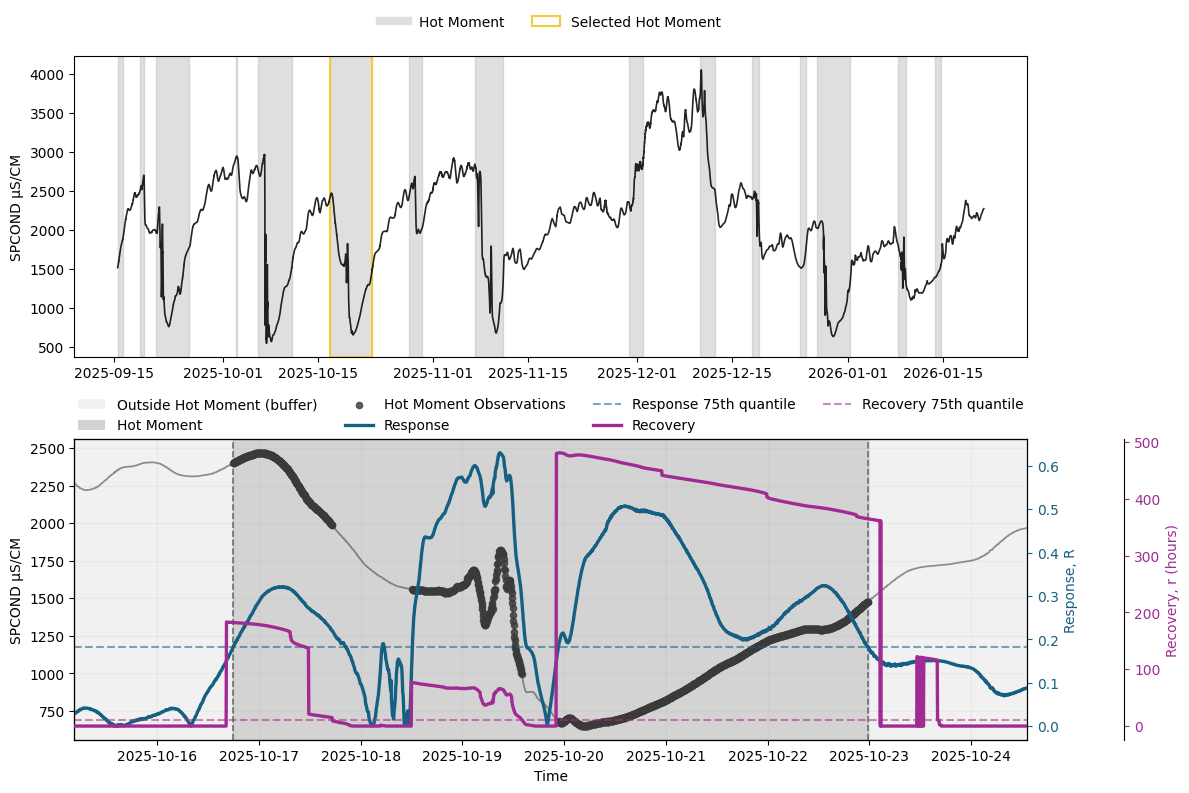

In [11]:
# This visualization adds a buffer around the hot moment and highlights the selected hot moment.

signal_color = "#3A3A3A"
response_color = "#156082"
recovery_color = "#A02B93"
obs_edge_color = "#3A3A3A"
event_color = "#B0B0B0"
buffer_color = "#D9D9D9"

# =========================
# Clean time indexing
# =========================
for site in site_data:
    site_data[site].index = site_data[site].index.tz_localize(None)

results["start_time"] = pd.to_datetime(results["start_time"]).dt.tz_localize(None)

# =========================
# Loop structure
# =========================
for w in hot_moments.keys():

    df_window = results[results["window_length"] == w]

    for site in hot_moments[w]:

        if site not in site_data:
            continue

        df_ts = site_data[site]
        df_site = df_window[df_window["site"] == site]

        for parameter in hot_moments[w][site]:

            if parameter not in df_ts.columns:
                continue

            event_windows = hot_moments[w][site][parameter]
            df_param = df_site[df_site["parameter"] == parameter]

            if len(event_windows) <= 5:
                continue

            # =========================
            # Select event
            # =========================
            event_start, event_end = event_windows[5]

            # =========================
            # Add buffer around event
            # =========================
            event_duration = event_end - event_start
            buffer = event_duration * 0.25

            zoom_start = event_start - buffer
            zoom_end = event_end + buffer

            # =========================
            # Data
            # =========================
            df_zoom = df_ts.loc[
                (df_ts.index >= zoom_start) &
                (df_ts.index <= zoom_end)
            ].copy()

            df_zoom_param = df_param[
                (df_param["start_time"] >= zoom_start) &
                (df_param["start_time"] <= zoom_end)
            ].copy()

            if df_zoom.empty or df_zoom_param.empty:
                continue

            # =========================
            # Thresholds
            # =========================
            R_thresh = df_param["response_q3"].iloc[0]
            r_thresh = df_param["recovery_q3"].iloc[0]

            # =========================
            # Figure
            # =========================
            fig, axes = plt.subplots(
                2, 1,
                figsize=(12, 8),
                sharex=False
            )

            # =========================================================
            # (A) Full time series
            # =========================================================
            axes[0].plot(
                df_ts.index,
                df_ts[parameter],
                color="black",
                linewidth=1.2,
                alpha=0.85
            )

            for s, e in event_windows:
                axes[0].axvspan(
                    s,
                    e,
                    color=event_color,
                    alpha=0.4
                )

            axes[0].plot(
                [],
                [],
                color=event_color,
                linewidth=6,
                alpha=0.4,
                label="Hot Moment"
            )

            ymin, ymax = axes[0].get_ylim()

            axes[0].add_patch(
                plt.Rectangle(
                    (event_start, ymin),
                    event_end-event_start,
                    ymax-ymin,
                    fill=False,
                    edgecolor="#F4CB38",
                    linewidth=1.5,
                    label="Selected Hot Moment"
                )
            )

            axes[0].set_ylabel(parameter)

            lines0, labels0 = axes[0].get_legend_handles_labels()
            axes[0].legend(
                lines0[:2],
                labels0[:2],
                frameon=False,
                loc="upper center",
                bbox_to_anchor=(0.5,1.18),
                ncol=2
            )


            # =========================================================
            # (B) Zoomed hot moment + buffer
            # =========================================================
            ax_signal = axes[1]
            ax_R = ax_signal.twinx()
            ax_r = ax_signal.twinx()

            ax_r.spines["right"].set_position(("outward",70))


            # -------------------------
            # Background regions
            # -------------------------

            # Before hot moment
            ax_signal.axvspan(
                zoom_start,
                event_start,
                color=buffer_color,
                alpha=0.35,
                zorder=0
            )

            # Hot moment
            ax_signal.axvspan(
                event_start,
                event_end,
                color=event_color,
                alpha=0.55,
                zorder=0
            )

            # After hot moment
            ax_signal.axvspan(
                event_end,
                zoom_end,
                color=buffer_color,
                alpha=0.35,
                zorder=0
            )

            # Event boundaries
            ax_signal.axvline(
                event_start,
                color="#555555",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8
            )

            ax_signal.axvline(
                event_end,
                color="#555555",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8
            )


            # -------------------------
            # Signal
            # -------------------------
            ax_signal.plot(
                df_zoom.index,
                df_zoom[parameter],
                color=signal_color,
                linewidth=1.25,
                alpha=0.55,
                zorder=2
            )


            # -------------------------
            # Response
            # -------------------------
            ax_R.plot(
                df_zoom_param["start_time"],
                df_zoom_param["response"],
                color=response_color,
                linewidth=2.4,
                zorder=4,
                label="Response"
            )

            ax_R.axhline(
                R_thresh,
                color=response_color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55,
                label="Response 75th quantile"
            )


            # -------------------------
            # Recovery
            # -------------------------
            ax_r.plot(
                df_zoom_param["start_time"],
                df_zoom_param["recovery"].dt.total_seconds()/3600,
                color=recovery_color,
                linewidth=2.4,
                zorder=4,
                label="Recovery"
            )

            ax_r.axhline(
                r_thresh,
                color=recovery_color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55,
                label="Recovery 75th quantile"
            )


            # -------------------------
            # Observations
            # -------------------------
            df_high = df_zoom_param[
                df_zoom_param["category"].isin(
                    ["HighR_LongRec","HighR_NoRec"]
                )
            ]

            if not df_high.empty:

                ts_index = df_zoom.index.to_numpy()
                ts_values = df_zoom[parameter].to_numpy()

                event_times = df_high["start_time"].to_numpy()

                idx = np.searchsorted(
                    ts_index,
                    event_times
                )

                idx = np.clip(
                    idx,
                    0,
                    len(ts_index)-1
                )

                ax_signal.scatter(
                    df_zoom.index[idx],
                    ts_values[idx],
                    s=20,
                    color=obs_edge_color,
                    alpha=0.8,
                    zorder=5,
                    label="Hot Moment Observations"
                )


            # =========================
            # Formatting
            # =========================
            ax_signal.set_xlim(
                zoom_start,
                zoom_end
            )

            ax_signal.set_ylabel(parameter)

            ax_R.set_ylabel(
                "Response, R",
                color=response_color
            )

            ax_r.set_ylabel(
                "Recovery, r (hours)",
                color=recovery_color
            )

            ax_signal.set_xlabel("Time")

            ax_signal.grid(alpha=0.15)

            ax_R.tick_params(
                axis="y",
                colors=response_color
            )

            ax_r.tick_params(
                axis="y",
                colors=recovery_color
            )


            # =========================
            # Legend
            # =========================
            from matplotlib.patches import Patch

            legend_handles = [
                Patch(
                    facecolor=buffer_color,
                    alpha=0.35,
                    label="Outside Hot Moment (buffer)"
                ),
                Patch(
                    facecolor=event_color,
                    alpha=0.55,
                    label="Hot Moment"
                )
            ]

            lines1, labels1 = ax_signal.get_legend_handles_labels()
            lines2, labels2 = ax_R.get_legend_handles_labels()
            lines3, labels3 = ax_r.get_legend_handles_labels()

            ax_signal.legend(
                legend_handles +
                lines1 +
                lines2 +
                lines3,
                [
                    h.get_label()
                    for h in legend_handles
                ] +
                labels1 +
                labels2 +
                labels3,
                frameon=False,
                loc="upper center",
                bbox_to_anchor=(0.5,1.18),
                ncol=4
            )


            plt.tight_layout()
            plt.show()